# Optimizer profile: parameter fraction and micro-batching
The two knobs that shrink the Jacobian: fewer columns (`param_fraction`) or fewer rows (`microbatch_size`).

In [1]:
import sys
import os
# This notebook lives in analysis/notebooks/<group>/, but every analysis path is
# relative to analysis/ (plots_v2/, tables/, ../experiment_results), so run from there
# with the helper modules in analysis/lib/ on the path.
_A = os.getcwd()
while not all(os.path.isdir(os.path.join(_A, d)) for d in ('lib', 'notebooks')):
    _A, _prev = os.path.dirname(_A), _A
    if _A == _prev:
        raise RuntimeError('analysis/ not found above ' + os.getcwd())
os.chdir(_A)
sys.path.insert(0, _A)
sys.path.insert(0, os.path.join(_A, 'lib'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from style import set_style
import profile_helpers as ph
set_style()
PLOT_DIR = 'plots_v2/profile'
# $SV3_PROFILE_ROOT > profile_results_v3 (the re-measurement, once its 720 configurations
# are all there) > profile_results_v2.  A PARTIAL v3 is announced and skipped, not used.
ROOT = ph.results_root()         # prints which root it chose
df = ph.load_profiles(ROOT)      # one tidy row per configuration
ARCHS = [a for a in ph.ARCH_ORDER if a in set(df.arch)]
df.groupby(['arch', 'study']).size().unstack(fill_value=0)

profile results: /n/home/anon/sven-experiments/profile_results_v3  (v3)


study,batch_size,chunk_fraction,k,methods,microbatch,param_fraction,width
arch,,,,,,,
cifar_resnet18,16,5,8,16,10,26,0
mnist,36,6,15,17,21,48,0
mnist_width,0,0,0,0,0,0,91
nanogpt,25,5,12,17,15,18,0
nanogpt_width,0,0,0,0,0,0,55
polynomial,36,4,15,17,18,39,0
toy_1d,36,4,15,17,18,39,0


### Parameter fraction
One line per Sven variant and mask structure (`elementwise`, `rows`, `tensor`). Dotted: the ideal cost proportional to the fraction, anchored at the unmasked point. Hooks-capture masking is not implemented for transformers, so nanoGPT shows the `jacrev` variants only.

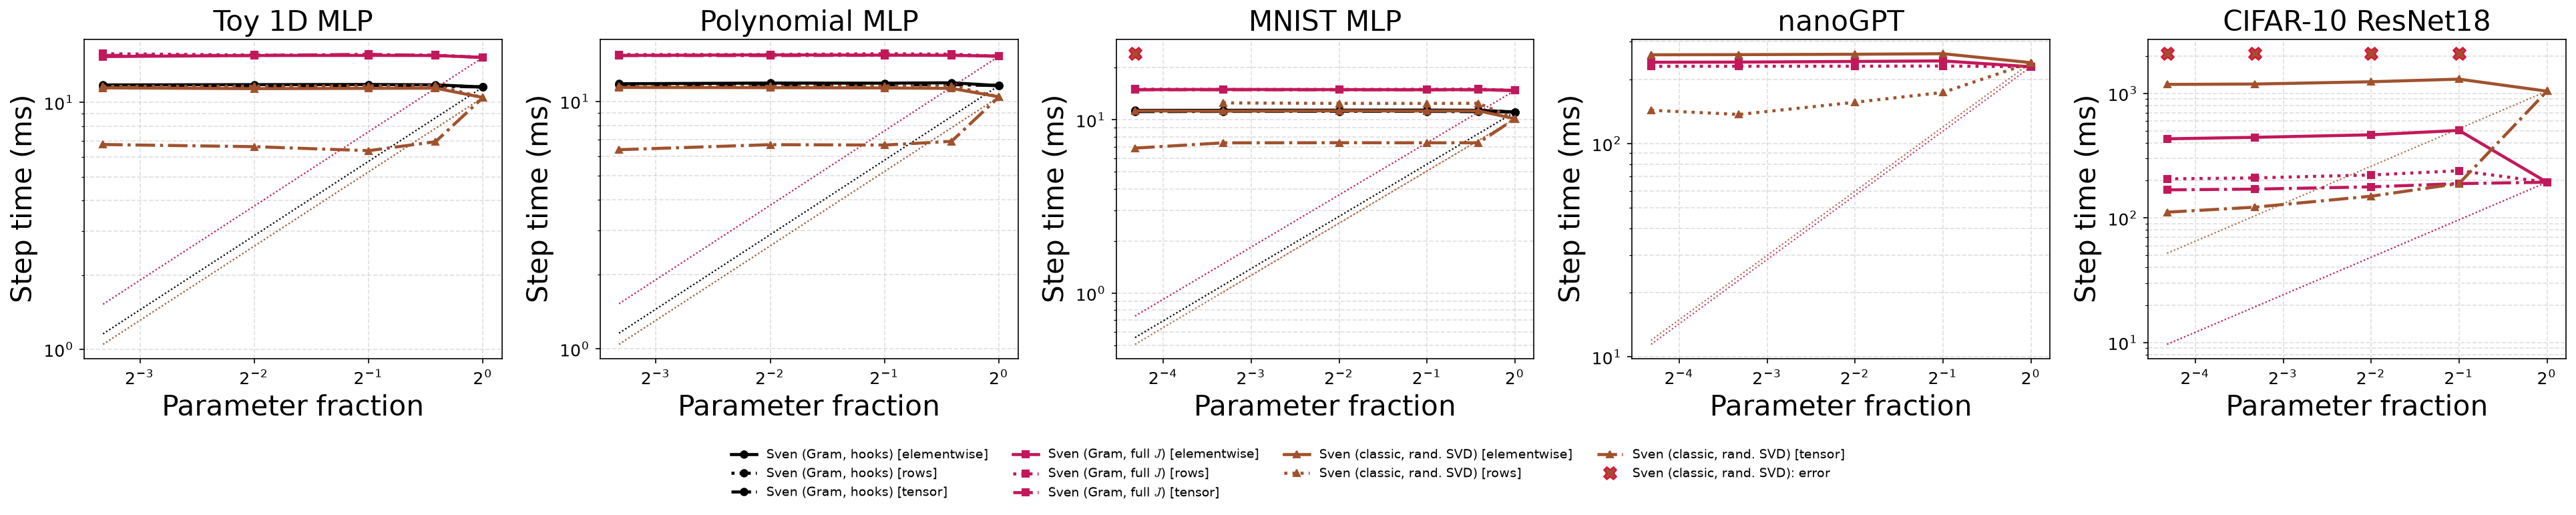

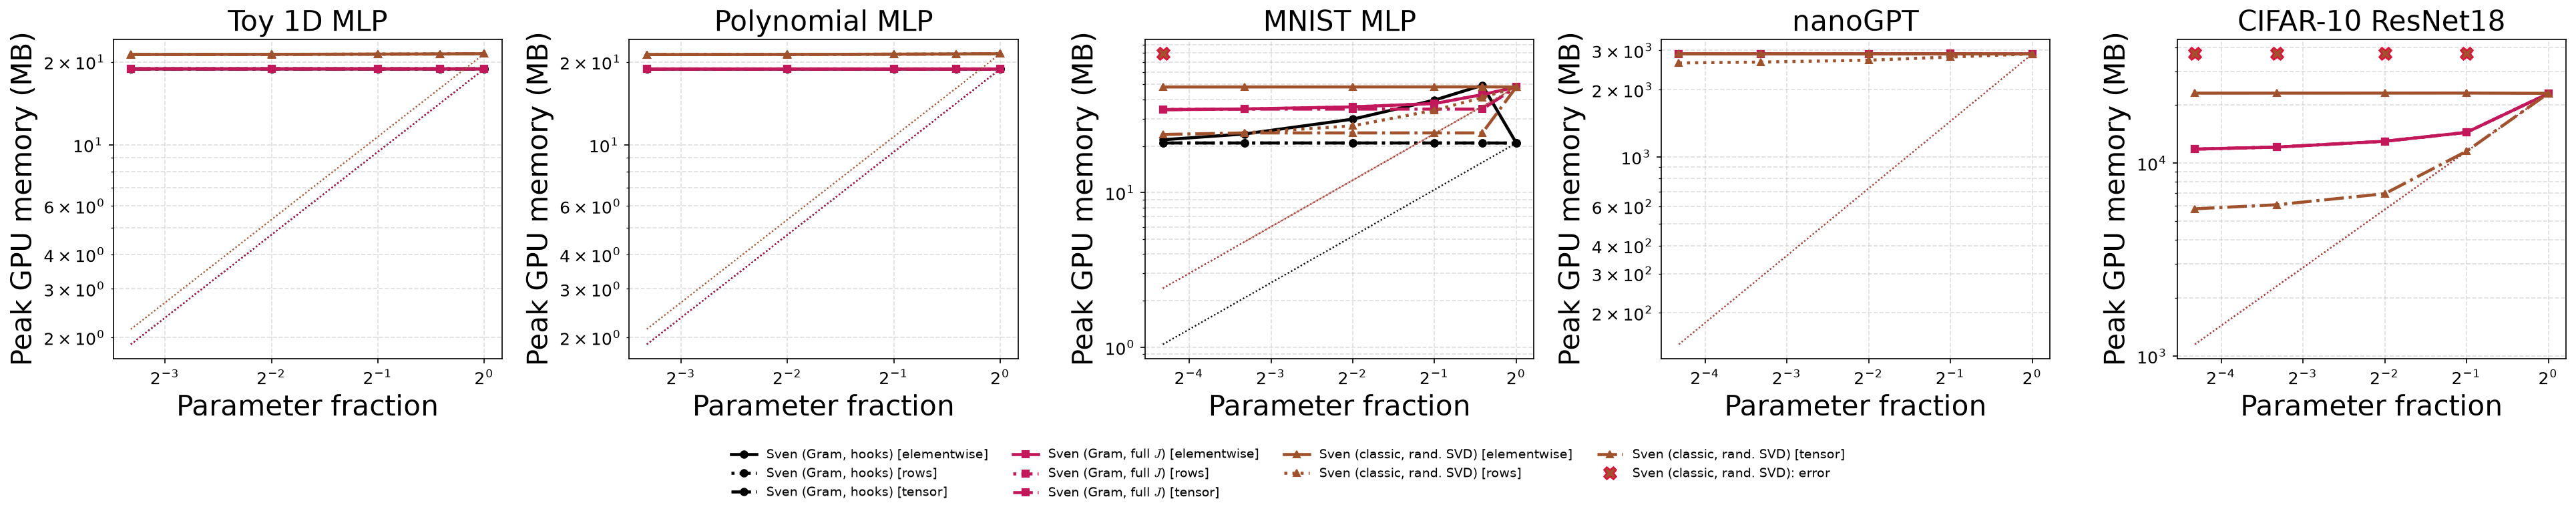

In [2]:
for value, fname in [('step_ms', 'paramfrac_step_time'), ('peak_mb', 'paramfrac_peak_memory')]:
    fig, axes = plt.subplots(1, len(ARCHS), figsize=(5.2 * len(ARCHS), 4.6), squeeze=False)
    for ax, arch in zip(axes[0], ARCHS):
        ph.plot_sweep(df, arch, 'param_fraction', 'pf', ax, value=value, style_by='mask_mode', ideal='linear')
    ph.legend_below(fig, axes[0][0])
    fig.tight_layout(); ph.save(fig, f'{fname}.pdf', PLOT_DIR); plt.show()

In [3]:
pf = df[df.study == 'param_fraction']
pf.pivot_table(index=['arch', 'method', 'mask_mode'], columns='pf', values='step_ms').round(2)

pf                                        0.05     0.10     0.25     0.50  \
arch           method     mask_mode                                         
cifar_resnet18 classic    elementwise  1179.20  1187.49  1238.46  1299.72   
                          none             NaN      NaN      NaN      NaN   
                          tensor        111.16   121.98   149.42   188.88   
               gram_full  elementwise   431.52   443.38   464.58   503.68   
                          none             NaN      NaN      NaN      NaN   
                          rows          205.79   209.53   221.06   239.24   
                          tensor        167.94   170.25   177.53   188.51   
mnist          classic    elementwise    11.26    11.22    11.26    11.24   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN    12.52    12.44    12.43   
                          tensor          6.87     7.36     7.38     7.37   
               gram_full  elementwise    14.92    14.97    14.92    14.90   
                          none             NaN      NaN      NaN      NaN   
                          rows           15.02    14.96    14.97    15.00   
                          tensor         14.92    14.91    14.91    14.91   
               gram_hooks elementwise    11.34    11.34    11.37    11.38   
                          none             NaN      NaN      NaN      NaN   
                          rows           11.23    11.24    11.25    11.32   
                          tensor         11.15    11.17    11.19    11.18   
nanogpt        classic    elementwise   260.58   260.99   262.07   263.59   
                          none             NaN      NaN      NaN      NaN   
                          tensor        143.12   136.88   156.12   173.55   
               gram_full  elementwise   240.41   240.77   242.50   243.92   
                          none             NaN      NaN      NaN      NaN   
                          tensor        229.98   230.16   230.37   230.80   
polynomial     classic    elementwise      NaN    11.38    11.35    11.32   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN    11.49    11.50    11.53   
                          tensor           NaN     6.37     6.68     6.66   
               gram_full  elementwise      NaN    15.32    15.40    15.36   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN    15.45    15.45    15.57   
                          tensor           NaN    15.31    15.30    15.35   
               gram_hooks elementwise      NaN    11.77    11.85    11.84   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN    11.71    11.76    11.75   
                          tensor           NaN    11.62    11.69    11.65   
toy_1d         classic    elementwise      NaN    11.45    11.37    11.40   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN    11.62    11.64    11.66   
                          tensor           NaN     6.75     6.62     6.37   
               gram_full  elementwise      NaN    15.34    15.49    15.50   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN    15.75    15.55    15.54   
                          tensor           NaN    15.50    15.49    15.66   
               gram_hooks elementwise      NaN    11.77    11.80    11.82   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN    11.72    11.71    11.76   
                          tensor           NaN    11.59    11.61    11.58   

pf                                      0.75     1.00  
arch           m

In [4]:
pf.pivot_table(index=['arch', 'method', 'mask_mode'], columns='pf', values='peak_mb').round(1)

pf                                        0.05     0.10     0.25     0.50  \
arch           method     mask_mode                                         
cifar_resnet18 classic    elementwise  23087.7  23090.0  23096.7  23107.8   
                          none             NaN      NaN      NaN      NaN   
                          tensor        5798.4   6084.7   6943.4  11534.6   
               gram_full  elementwise  11827.5  12118.2  12990.4  14444.0   
                          none             NaN      NaN      NaN      NaN   
                          rows         11830.8  12118.1  12990.3  14444.0   
                          tensor       11827.5  12118.2  12990.4  14443.4   
mnist          classic    elementwise     48.2     48.2     48.2     48.2   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN     24.4     27.0     34.1   
                          tensor          23.7     24.3     24.3     24.3   
               gram_full  elementwise     34.3     34.7     35.8     37.6   
                          none             NaN      NaN      NaN      NaN   
                          rows            34.4     34.7     35.8     37.6   
                          tensor          34.3     34.6     34.6     34.6   
               gram_hooks elementwise     21.9     23.9     29.8     39.6   
                          none             NaN      NaN      NaN      NaN   
                          rows            20.9     20.9     20.9     20.9   
                          tensor          20.9     20.9     20.9     20.9   
nanogpt        classic    elementwise   2896.4   2896.6   2897.1   2897.9   
                          none             NaN      NaN      NaN      NaN   
                          tensor        2635.0   2658.1   2711.3   2800.7   
               gram_full  elementwise   2893.3   2893.6   2894.6   2896.3   
                          none             NaN      NaN      NaN      NaN   
                          tensor        2893.3   2893.6   2894.6   2896.3   
polynomial     classic    elementwise      NaN     21.3     21.3     21.4   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN     21.3     21.3     21.4   
                          tensor           NaN     21.3     21.3     21.3   
               gram_full  elementwise      NaN     18.9     18.9     18.9   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN     18.9     18.9     18.9   
                          tensor           NaN     18.9     18.9     18.9   
               gram_hooks elementwise      NaN     18.9     18.9     18.9   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN     18.9     18.9     18.9   
                          tensor           NaN     18.9     18.9     18.9   
toy_1d         classic    elementwise      NaN     21.3     21.3     21.3   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN     21.3     21.3     21.3   
                          tensor           NaN     21.3     21.3     21.3   
               gram_full  elementwise      NaN     18.9     18.9     18.9   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN     18.9     18.9     18.9   
                          tensor           NaN     18.9     18.9     18.9   
               gram_hooks elementwise      NaN     18.9     18.9     18.9   
                          none             NaN      NaN      NaN      NaN   
                          rows             NaN     18.9     18.9     18.9   
                          tensor           NaN     18.9     18.9     18.9   

pf                                     0.75     1.00  
arch           me

### Micro-batch size
Rows shrink from $B$ to $B/\mathrm{mb}$ for the `jacrev` variants. Hooks capture always builds the $B\times B$ per-sample kernel and pools it afterwards, so its cost should be flat.

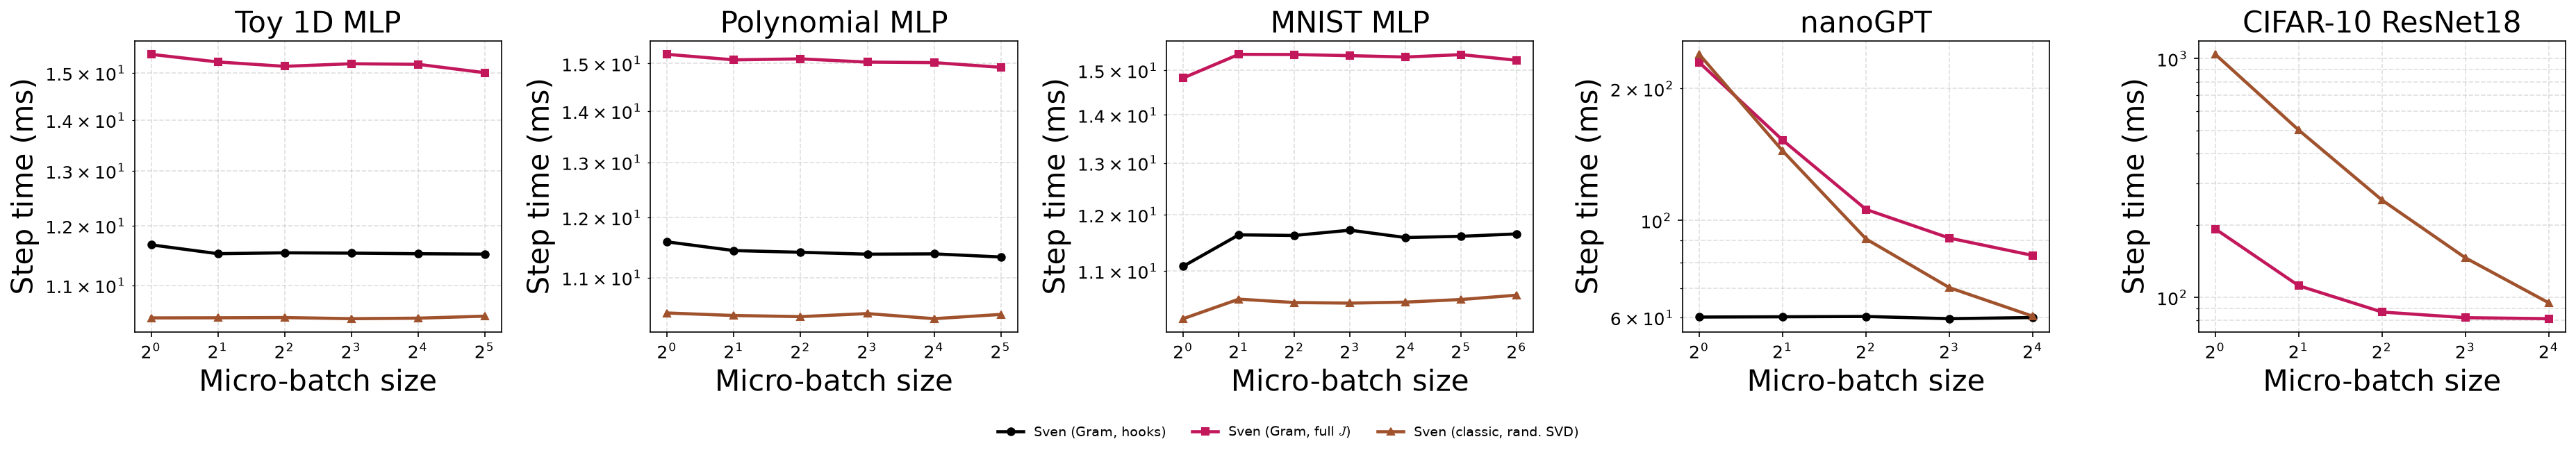

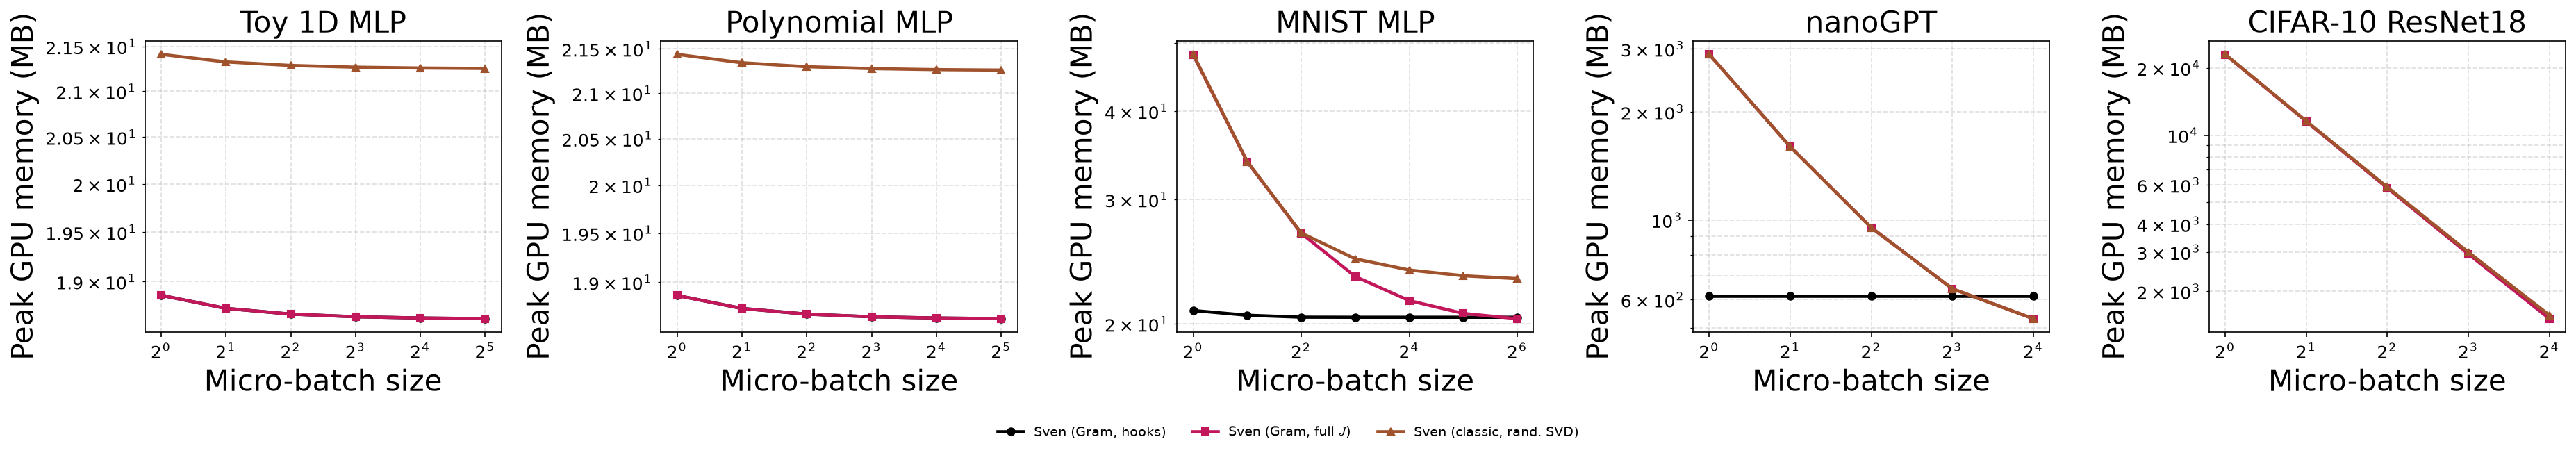

In [5]:
for value, fname in [('step_ms', 'microbatch_step_time'), ('peak_mb', 'microbatch_peak_memory')]:
    fig, axes = plt.subplots(1, len(ARCHS), figsize=(5 * len(ARCHS), 4.2), squeeze=False)
    for ax, arch in zip(axes[0], ARCHS):
        ph.plot_sweep(df, arch, 'microbatch', 'mb', ax, value=value)
    ph.legend_below(fig, axes[0][0])
    fig.tight_layout(); ph.save(fig, f'{fname}.pdf', PLOT_DIR); plt.show()

In [6]:
df[df.study == 'microbatch'].pivot_table(index=['arch', 'method'], columns='mb', values='step_ms').round(2)

mb                              1       2       4       8      16     32  \
arch           method                                                      
cifar_resnet18 classic     1040.93  501.47  255.03  146.09  94.65    NaN   
               gram_full    193.22  111.72   86.65   82.08  81.28    NaN   
mnist          classic       10.22   10.53   10.48   10.47  10.48  10.53   
               gram_full     14.82   15.37   15.37   15.34  15.31  15.37   
               gram_hooks    11.08   11.63   11.62   11.72  11.58  11.61   
nanogpt        classic      239.33  144.05   90.66   70.17  60.38    NaN   
               gram_full    229.29  152.43  105.88   91.08  83.13    NaN   
               gram_hooks    60.13   60.21   60.31   59.62  59.99    NaN   
polynomial     classic       10.45   10.41   10.39   10.44  10.36  10.43   
               gram_full     15.20   15.08   15.10   15.03  15.02  14.92   
               gram_hooks    11.58   11.44   11.41   11.38  11.38  11.33   
toy_1d         classic       10.49   10.49   10.50   10.48  10.49  10.52   
               gram_full     15.41   15.24   15.14   15.20  15.19  15.00   
               gram_hooks    11.67   11.52   11.54   11.53  11.52  11.51   

mb                            64  
arch           method             
cifar_resnet18 classic       NaN  
               gram_full     NaN  
mnist          classic     10.60  
               gram_full   15.23  
               gram_hooks  11.65  
nanogpt        classic       NaN  
               gram_full     NaN  
               gram_hooks    NaN  
polynomial     classic       NaN  
               gram_full     NaN  
               gram_hooks    NaN  
toy_1d         classic       NaN  
               gram_full     NaN  
               gram_hooks    NaN

### Combinations that are not supported

In [7]:
ph.status_report(df[df.study.isin(['param_fraction', 'microbatch'])])

,arch,study,method,B,pf,mask_mode,mb,width,status,error
0,cifar_resnet18,param_fraction,classic,128,0.05,rows,1,NaN,error,NotImplementedError: module 'bn1' (BatchNorm2d...
1,cifar_resnet18,param_fraction,classic,128,0.10,rows,1,NaN,error,NotImplementedError: module 'bn1' (BatchNorm2d...
2,cifar_resnet18,param_fraction,classic,128,0.25,rows,1,NaN,error,NotImplementedError: module 'bn1' (BatchNorm2d...
3,cifar_resnet18,param_fraction,classic,128,0.50,rows,1,NaN,error,NotImplementedError: module 'bn1' (BatchNorm2d...
4,mnist,param_fraction,classic,64,0.05,rows,1,NaN,error,_LinAlgError: linalg.eigh: The algorithm faile...
